# Telecom Customer Churn — Exploratory Data Analysis (EDA)

- understand the patterns and factors contributing to customer churn in the telecom_churn dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 # 1. Data Loading & Initial Inspection

## Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

## Define File Paths

In [ ]:
# expresso_sample_file = "/path/to/expresso_sample.csv"
# telecom_churn_file = "/path/to/telecom_churn.csv"
# telecom_churn_100k_file = "/path/to/telecom_churn_100k.csv"


## Load dataset

In [ ]:
telecom_churn_100k = pd.read_csv(telecom_churn_100k_file)

## Basic structure

In [ ]:
telecom_churn_100k.head()

,user_id,region,tenure,montant,frequence_rech,revenue,arpu_segment,frequence,data_volume,on_net,orange,tigo,zone1,zone2,mrg,regularity,top_pack,freq_top_pack,region_tower_count,region_avg_range,region_avg_samples,region_avg_signal,region_coverage_index,region_signal_strength_index,region_network_quality_score,department_signal_strength_index,department_network_quality_score,department_coverage_index,arr_signal_strength_index,arr_network_quality_score,arr_coverage_index,churn
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,K > 24 month,8650.0,37.0,8650.0,2883.0,38.0,2593.0,3.0,39.0,1.0,NaN,NaN,NO,59,"Data: 100 F=40MB,24H",20.0,1771.0,1347.316206,6.294184,0.0,2386097.0,0.0,533.188255,0.0,134.914073,2386097.0,0.0,55.106100,2386097.0,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,K > 24 month,1000.0,2.0,980.0,327.0,2.0,1362.0,NaN,1.0,9.0,NaN,NaN,NO,8,"Data:490F=1GB,7d",2.0,4.0,1239.000000,1.750000,0.0,4956.0,0.0,1.725000,0.0,1.050000,4956.0,0.0,1.050000,4956.0,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,1043.0,4.0,NaN,NaN,NaN,NaN,NO,8,NaN,NaN,4.0,1239.000000,1.750000,0.0,4956.0,0.0,1.725000,0.0,1.050000,4956.0,0.0,1.050000,4956.0,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,K > 24 month,250.0,1.0,250.0,83.0,2.0,389.0,5.0,NaN,NaN,NaN,NaN,NO,58,"Data: 200 F=100MB,24H",1.0,94.0,4254.223404,3.776596,0.0,399897.0,0.0,29.332979,0.0,10.543254,399897.0,0.0,4.315221,399897.0,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NO,15,NaN,NaN,1771.0,1347.316206,6.294184,0.0,2386097.0,0.0,533.188255,0.0,134.914073,2386097.0,0.0,55.106100,2386097.0,1


In [ ]:
telecom_churn_100k.shape

(100000, 32)

In [ ]:
telecom_churn_100k.dtypes

,0
user_id,object
region,object
tenure,object
montant,float64
frequence_rech,float64
revenue,float64
arpu_segment,float64
frequence,float64
data_volume,float64
on_net,float64


In [ ]:
telecom_churn_100k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           100000 non-null  object 
 1   region                            60844 non-null   object 
 2   tenure                            100000 non-null  object 
 3   montant                           65059 non-null   float64
 4   frequence_rech                    65059 non-null   float64
 5   revenue                           66484 non-null   float64
 6   arpu_segment                      66484 non-null   float64
 7   frequence                         66484 non-null   float64
 8   data_volume                       50813 non-null   float64
 9   on_net                            63663 non-null   float64
 10  orange                            58621 non-null   float64
 11  tigo                              40369 non-null   fl

In [ ]:
print(f'Memory: {telecom_churn_100k.memory_usage(deep=True).sum()/1e6:.1f} MB')

Memory: 51.9 MB


## Check Missing values

In [ ]:
missing = pd.DataFrame({
    "Missing #": telecom_churn_100k.isna().sum(),
    "Missing %": telecom_churn_100k.isna().mean().mul(100).round(2),
    "dtype":     telecom_churn_100k.dtypes,
}).sort_values("Missing %", ascending=False)
missing = missing[missing["Missing #"] > 0]
missing

,Missing #,Missing %,dtype
zone2,93507,93.51,float64
zone1,92091,92.09,float64
tigo,59631,59.63,float64
data_volume,49187,49.19,float64
freq_top_pack,41736,41.74,float64
top_pack,41736,41.74,object
orange,41379,41.38,float64
region,39156,39.16,object
on_net,36337,36.34,float64
montant,34941,34.94,float64


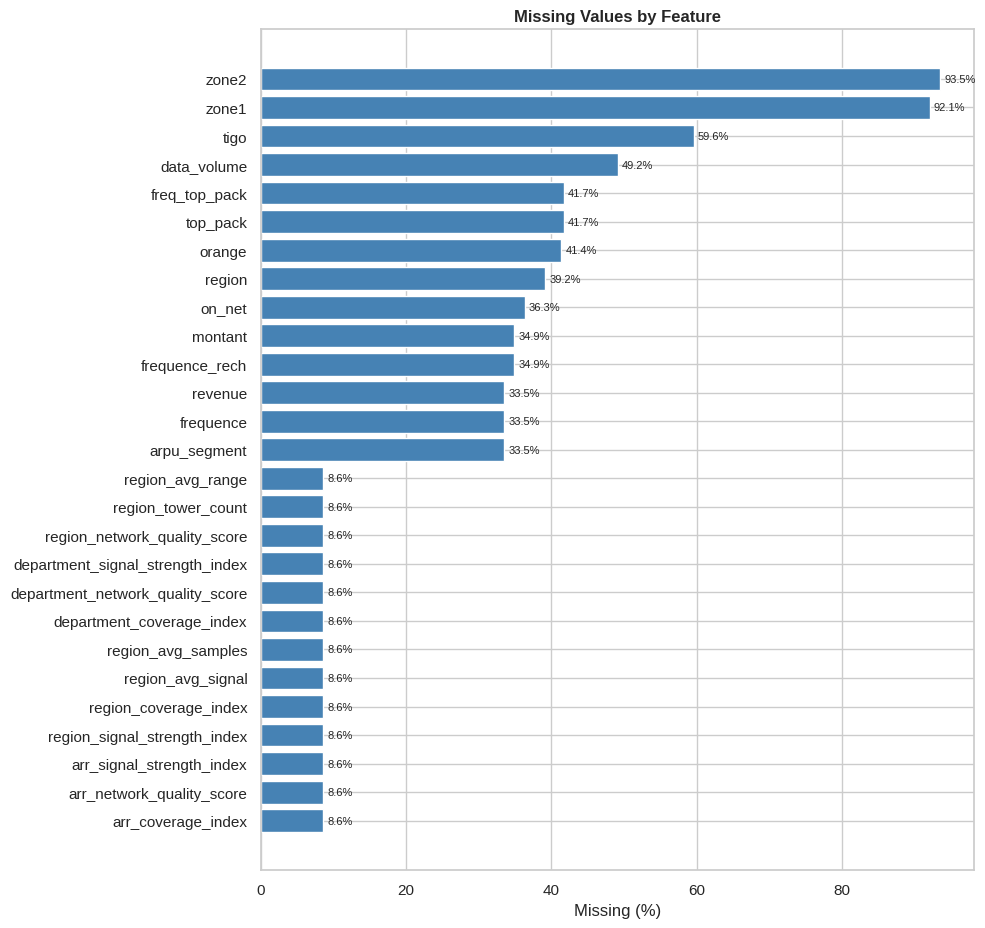

In [ ]:
fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.35)))
bars = ax.barh(missing.index, missing["Missing %"], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Feature", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Key Missing Values Findings


- **zone1** and **zone2** are too sparse
- Drop **zone1** and **zone2** before modeling



- tigo: Impute median or add is_missing flag
- data_volume: Impute 0 + binary flag (no-data user)
- top_pack: Impute 'Unknown' category
- orange: Impute median
- montant: Impute median
- frequence_rech: Impute median
- on_net: Impute median
- region: Impute mode or encode as 'Unknown'

## Check Duplicate rows



In [ ]:
print('Duplicates:', telecom_churn_100k.duplicated().sum())

Duplicates: 0


# Check Zero-variance columns

In [ ]:
zero_var = [c for c in telecom_churn_100k.select_dtypes('object') if telecom_churn_100k[c].nunique() == 1]
print('Zero-variance columns:', zero_var)

Zero-variance columns: ['mrg']


- **mrg** is zero-variance (100% 'NO') and carries no information.
- Drop **mrg** before modeling.



# 2. Summary Statistics

## Numerical

In [ ]:
telecom_churn_100k.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
montant,65059.0,5529.50,7175.85,50.00,1000.00,3000.00,7300.00,226550.00
frequence_rech,65059.0,11.56,13.31,1.00,2.00,7.00,16.00,132.00
revenue,66484.0,5508.25,7259.06,1.00,1000.00,3000.00,7301.00,233413.00
arpu_segment,66484.0,1836.09,2419.68,0.00,333.00,1000.00,2434.00,77804.00
frequence,66484.0,14.01,14.72,1.00,3.00,9.00,20.00,91.00
data_volume,50813.0,3385.93,12533.67,0.00,0.00,256.00,2927.00,926547.00
on_net,63663.0,279.01,871.24,0.00,5.00,27.00,158.00,36687.00
orange,58621.0,94.75,202.44,0.00,7.00,28.00,98.00,5299.00
tigo,40369.0,23.24,64.46,0.00,2.00,6.00,20.00,1963.00
zone1,7909.0,8.10,35.66,0.00,0.00,1.00,4.00,1204.00


## Catagorical

In [ ]:
telecom_churn_100k.describe(include="object").T.round(2)

,count,unique,top,freq
user_id,100000,100000,a7b094f613ee1a96f264365d93b4bf402836f315,1
region,60844,14,DAKAR,23859
tenure,100000,8,K > 24 month,94855
mrg,100000,1,NO,100000
top_pack,58264,90,All-net 500F=2000F;5d,14703


- **user_id** is a User Identifier
- Drop **user_id** before modeling

# 3. Target Variable Analysis — Churn

## Churn Distribution

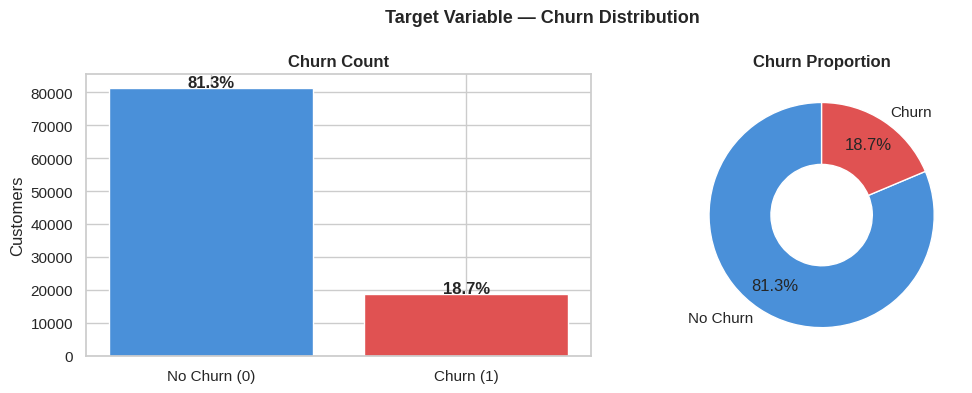


Churn rate: 18.7%  →  IMBALANCED


In [ ]:
churn_counts = telecom_churn_100k['churn'].value_counts()
churn_pct    = telecom_churn_100k['churn'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ["#4A90D9", "#E05252"]
axes[0].bar(["No Churn (0)", "Churn (1)"], churn_counts.values, color=colors, edgecolor="white")
for i, (cnt, pct) in enumerate(zip(churn_counts, churn_pct)):
    axes[0].text(i, cnt + 300, f"{pct}%", ha="center", fontweight="bold")
axes[0].set_title("Churn Count", fontweight="bold")
axes[0].set_ylabel("Customers")

# Pie chart
axes[1].pie(churn_counts, labels=["No Churn", "Churn"], colors=colors,
            autopct="%1.1f%%", startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.55))   # donut style
axes[1].set_title("Churn Proportion", fontweight="bold")

plt.suptitle("Target Variable — Churn Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nChurn rate: {churn_pct[1]:.1f}%  →  "
      f"{'Balanced' if 30 <= churn_pct[1] <= 70 else 'IMBALANCED'}")


### Key Churn Distribution Findings


- the **0 — No Churn** Class is the **Majority** class while the **1 — Churn** is the Minority class with **~19%** churn = moderate class imbalance.

- Use **stratified** train/test split or class_weight='**balanced**'

- Evaluate with **F1, ROC-AUC, precision and recall**



# 4. Univariate Analysis

## Numerical Features

In [ ]:
num_cols = [col for col in telecom_churn_100k.select_dtypes(include=np.number).columns if col != 'churn']
num_cols

['montant',
 'frequence_rech',
 'revenue',
 'arpu_segment',
 'frequence',
 'data_volume',
 'on_net',
 'orange',
 'tigo',
 'zone1',
 'zone2',
 'regularity',
 'freq_top_pack',
 'region_tower_count',
 'region_avg_range',
 'region_avg_samples',
 'region_avg_signal',
 'region_coverage_index',
 'region_signal_strength_index',
 'region_network_quality_score',
 'department_signal_strength_index',
 'department_network_quality_score',
 'department_coverage_index',
 'arr_signal_strength_index',
 'arr_network_quality_score',
 'arr_coverage_index']

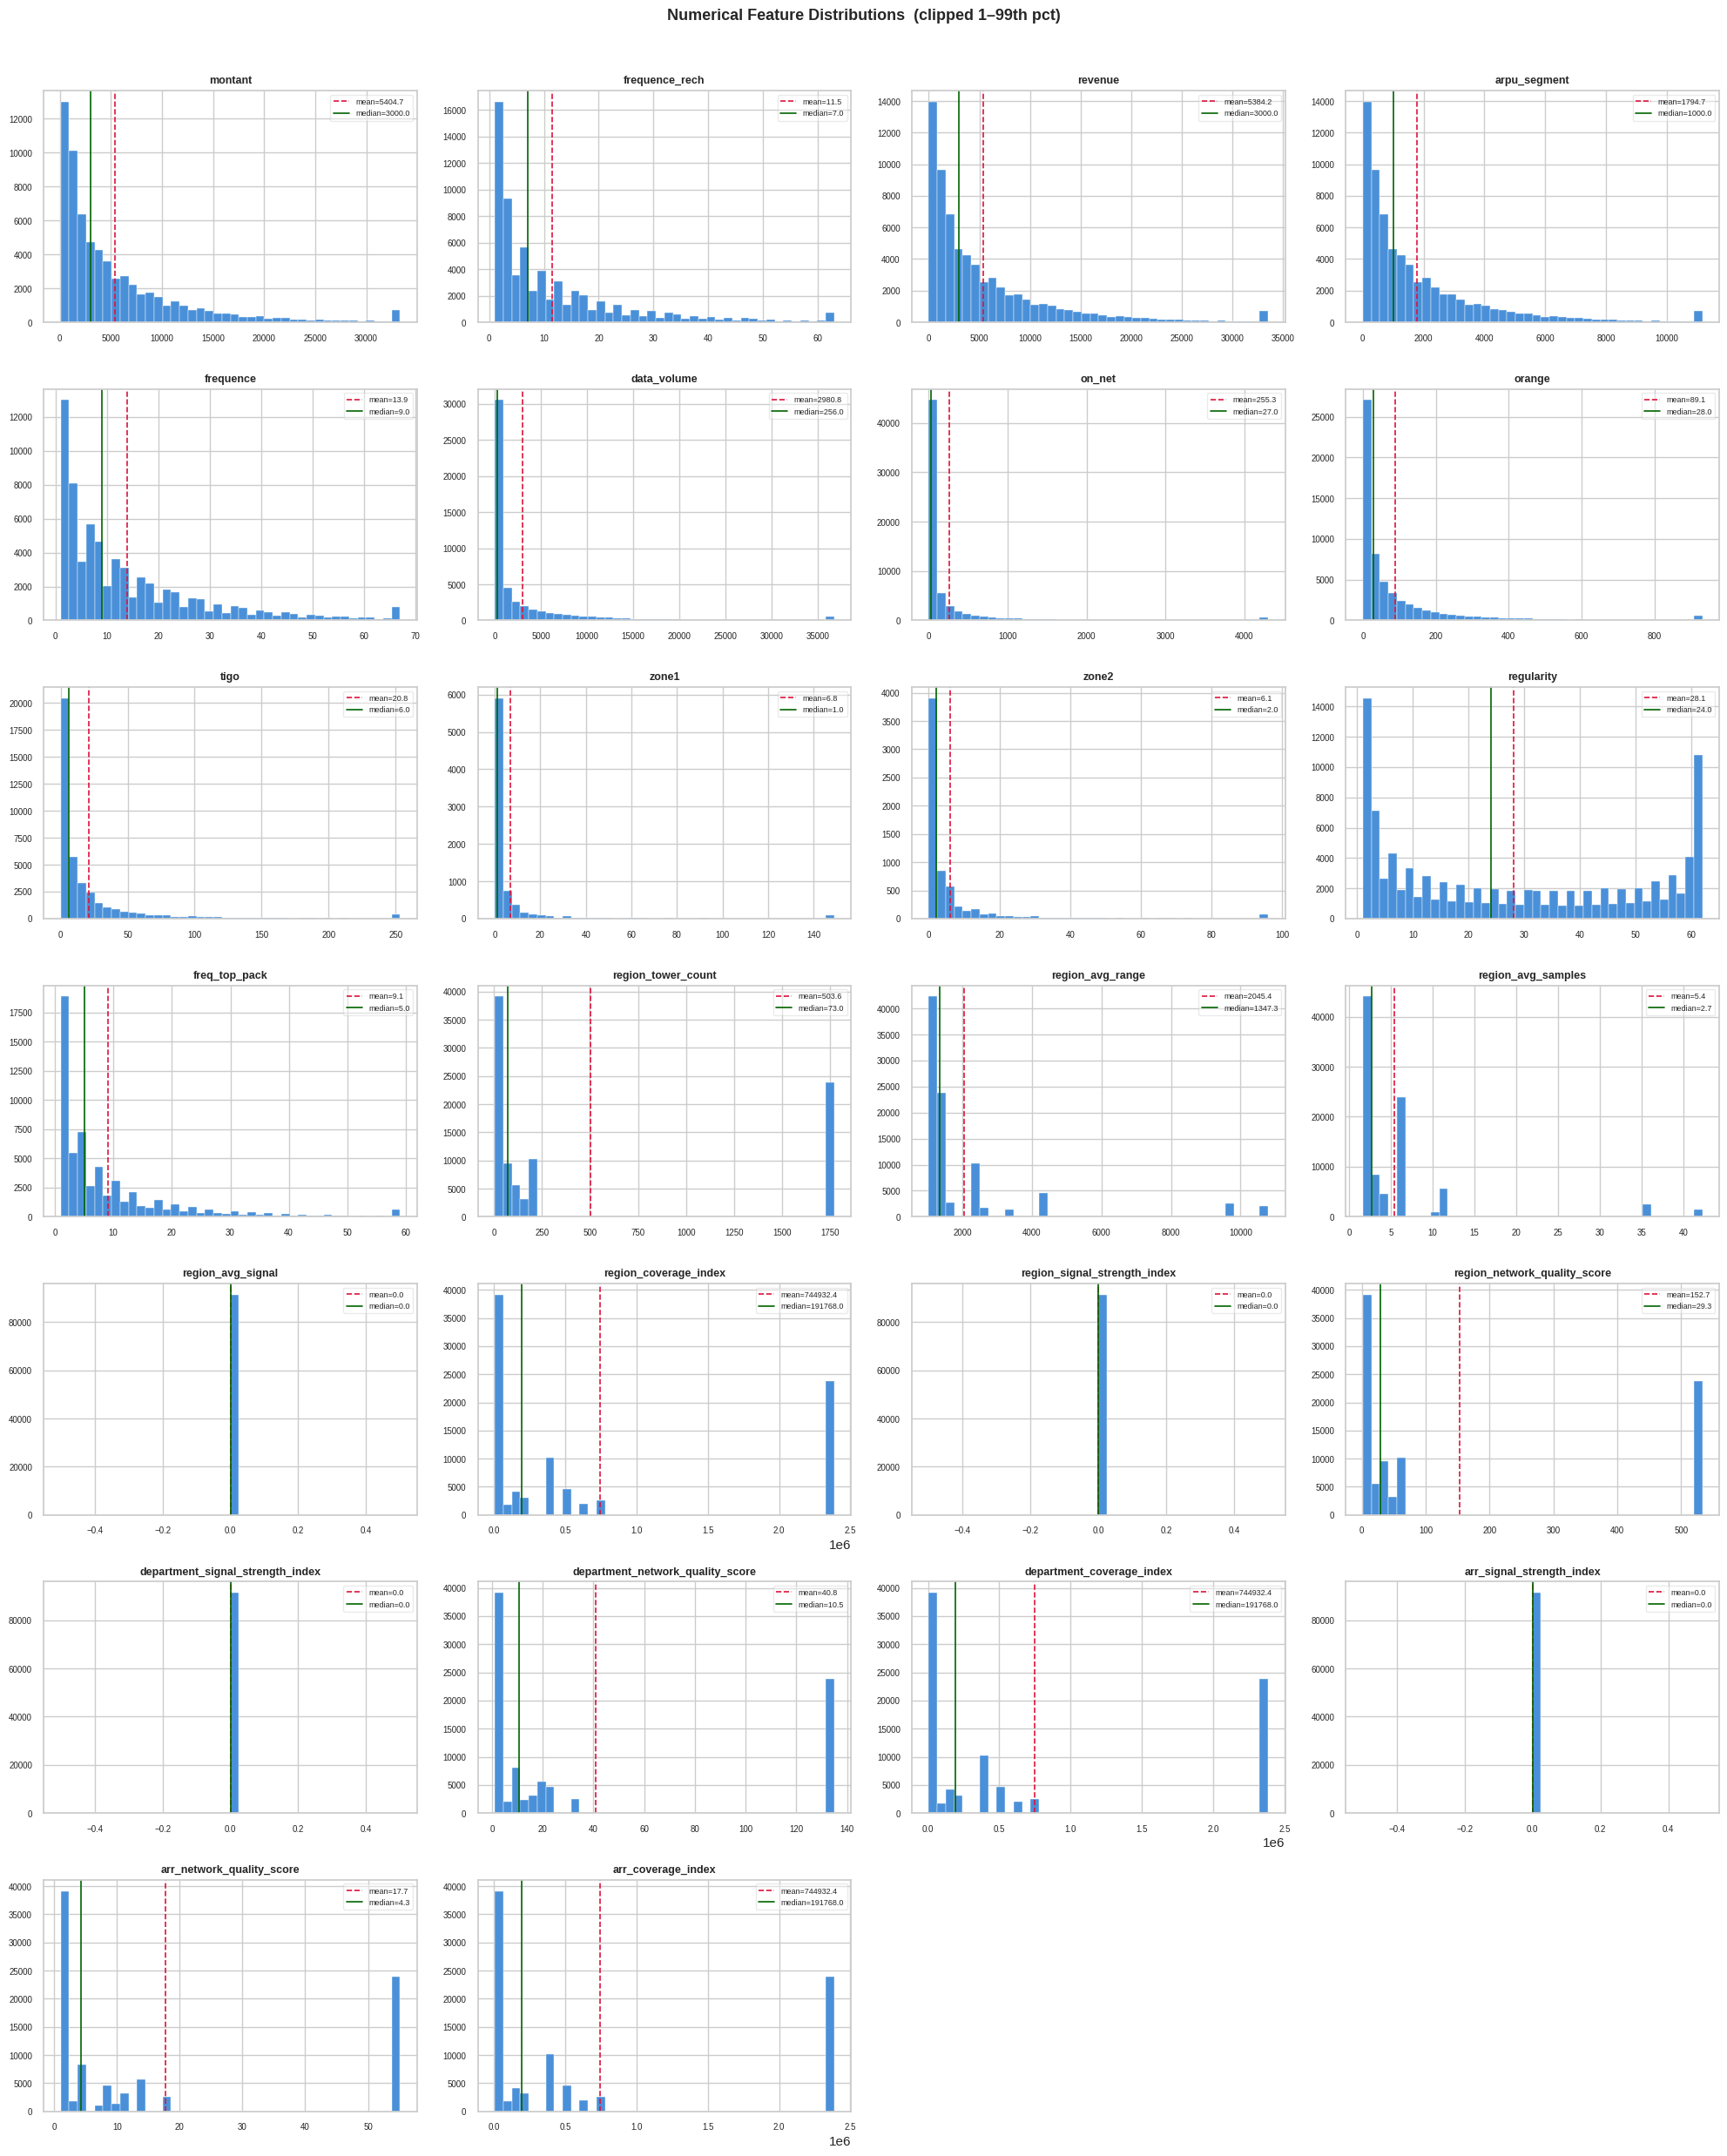

In [ ]:
# Use 4-column grid
n_cols  = 4
n_rows  = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = telecom_churn_100k[col].dropna()

    # Clip extreme outliers for visual clarity (keep 1st–99th percentile)
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    clipped  = data.clip(p1, p99)

    axes[i].hist(clipped, bins=40, color="#4A90D9", edgecolor="white", linewidth=0.3)

    # Overlay mean & median lines
    axes[i].axvline(clipped.mean(),   color="crimson",    ls="--", lw=1.2,
                    label=f"mean={clipped.mean():.1f}")
    axes[i].axvline(clipped.median(), color="darkgreen", ls="-",  lw=1.2,
                    label=f"median={clipped.median():.1f}")

    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)
    axes[i].legend(fontsize=6.5, framealpha=0.4)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions  (clipped 1–99th pct)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Key Numerical Features Distribution Findings
| Feature | Shape | Mean | Median | Observation |
| :--- | :--- | :--- | :--- | :--- |
| **montant** | Right-skewed | 5,529 | 3,000 | Long tail; heavy users dominate spend |
| **revenue** | Right-skewed | 5,508 | 3,000 | Mirrors montant — high multicollinearity |
| **frequence_rech** | Right-skewed | 11.6 | 7 | Most users recharge < 10x/month |
| **data_volume** | Bimodal | 3,386 | 256 | Large spike at 0 (non-data users) |
| **regularity** | Near-uniform | 28.2 | 24 | Spread 1-62; strongest churn signal |
| **on_net** | Right-skewed | 279 | 27 | Extreme outliers (max 36,687) |
| **region_*_signal** | Zero-var | 0.00 | 0.00 | Constant — drop all 3 signal columns |

- **region_avg_signal, region_signal_strength_index, department_signal_strength_index, and arr_signal_strength_index** all have min=max=**0.00**.
- These are zero-variance and must be dropped before modeling.



## Categorical Features

In [ ]:
# Skip user_id
cat_cols = ['region', 'tenure', 'mrg', 'top_pack']

# Limit top_pack to top N categories to show only top 10 for high-cardinality cols
top_n = {'top_pack': 10}

n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols

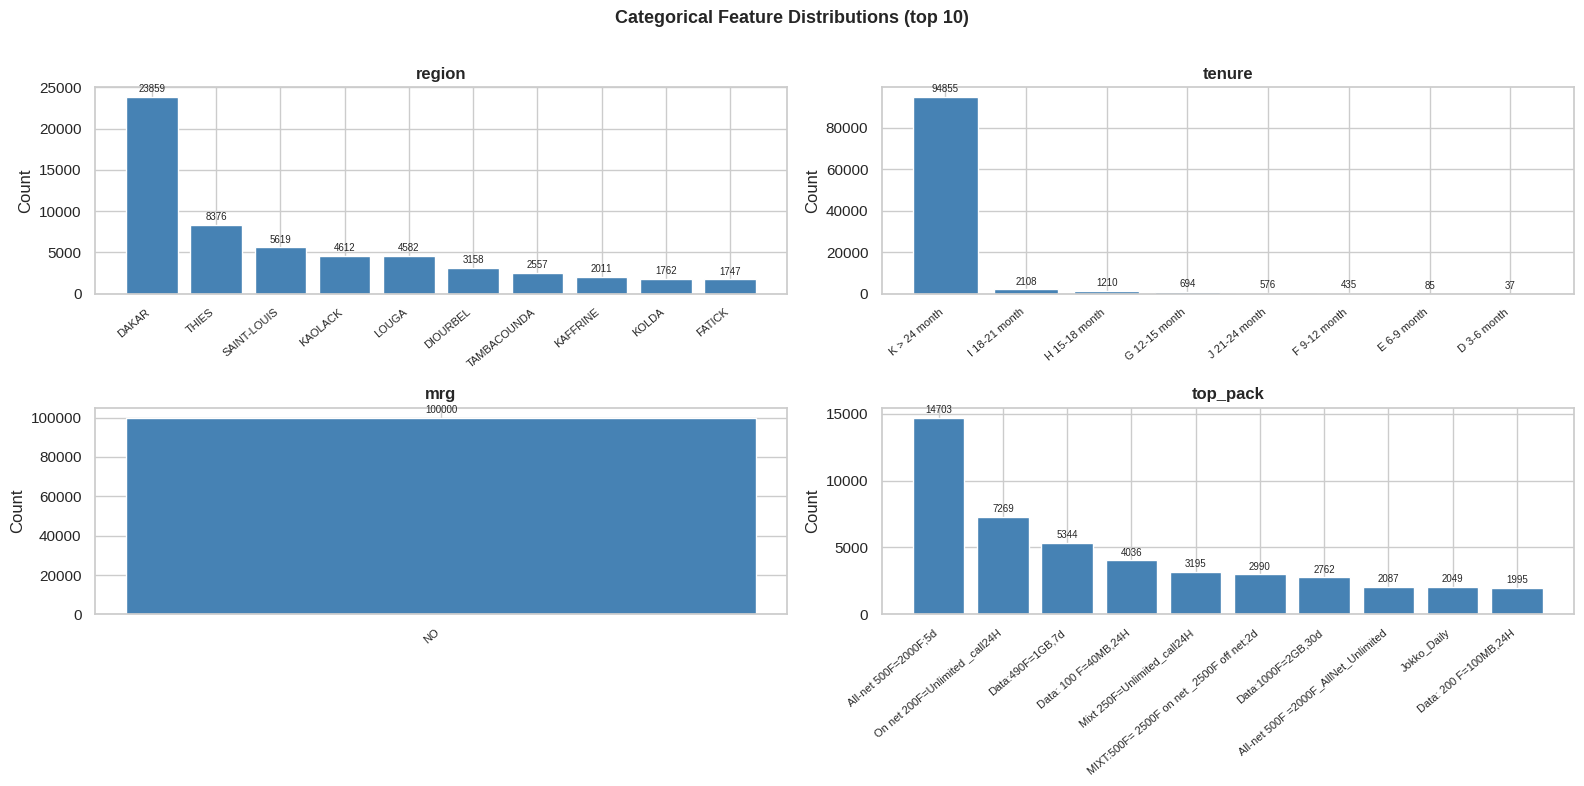

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    n = top_n.get(col, 10)  # default top 10
    counts = telecom_churn_100k[col].value_counts().head(n)
    bars   = axes[i].bar(range(len(counts)), counts.values,
                         color="steelblue", edgecolor="white")
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=40, ha="right", fontsize=8)
    axes[i].set_title(f"{col}", fontweight="bold")
    axes[i].set_ylabel("Count")
    axes[i].bar_label(bars, fmt="%d", padding=2, fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Feature Distributions (top 10)\n", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Key Categorical Features Distribution Findings

| Feature | Unique | Top Value | Top Freq | Note |
| :--- | :--- | :--- | :--- | :--- |
| **user_id** | 100,000 | — | 1 | Identifier — exclude |
| **region** | 14 | DAKAR | 23,859 | Dakar is 39% of region-known records |
| **tenure** | 8 | K > 24 month | 94,855 | 94.9% in longest tenure — near-constant |
| **mrg** | 1 | NO | 100,000 | Zero-variance — DROP |
| **top_pack** | 90 | All-net 500F=2000F;5d | 14,703 | High cardinality; target-encode |

- **tenure** is 94.9% 'K > 24 month'.
- This near-zero variance makes it unlikely to be informative as-is.
- Consider collapsing to binary (loyal vs. new) or dropping it.



# 5. Bivariate Analysis

## Numerical vs churn

In [ ]:
BIVARIATE_COLS = ["montant", "revenue", "frequence", "data_volume",
                  "regularity", "freq_top_pack", "on_net", "orange"]

N_COLS_BI = 4
n_rows_bi  = (len(BIVARIATE_COLS) + N_COLS_BI - 1) // N_COLS_BI

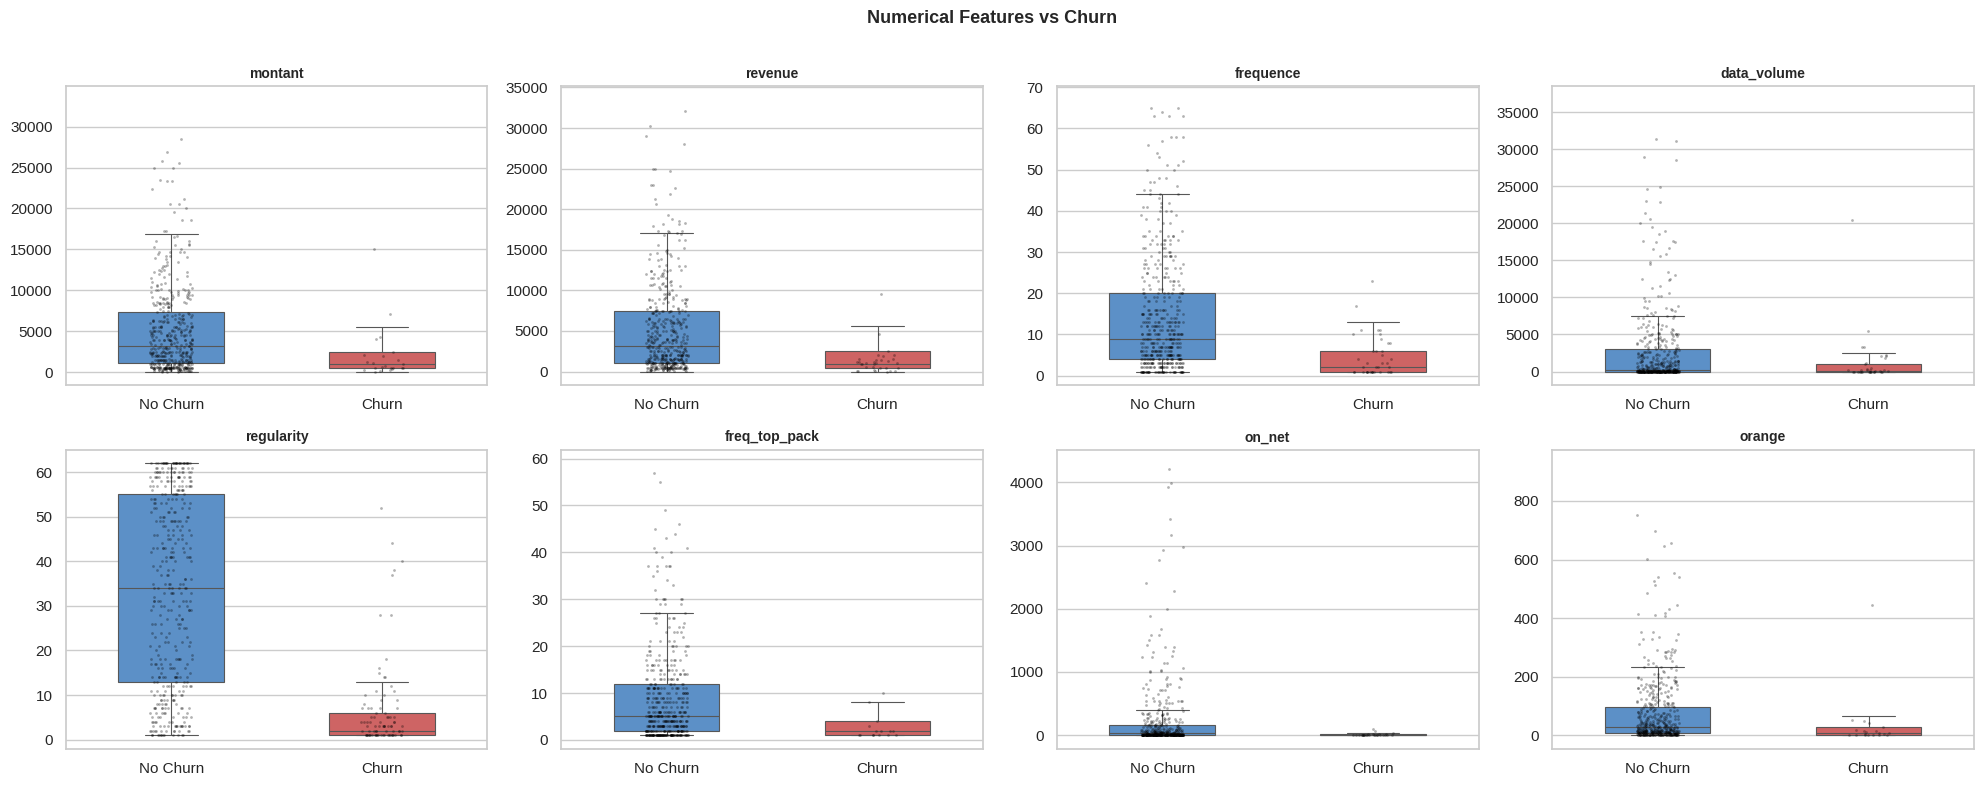

In [ ]:
fig, axes = plt.subplots(n_rows_bi, N_COLS_BI, figsize=(20, n_rows_bi * 4))
axes = axes.flatten()

palette = {0: "#4A90D9", 1: "#E05252"}

for i, col in enumerate(BIVARIATE_COLS):
    sub = telecom_churn_100k[[col, 'churn']].dropna()
    p1, p99 = sub[col].quantile(0.01), sub[col].quantile(0.99)
    sub = sub[sub[col].between(p1, p99)]

    # Force churn to int to match the palette keys exactly
    sub['churn'] = sub['churn'].astype(int)

    # Use Boxplot to show (Median, IQR, Range)
    sns.boxplot(data=sub, x='churn', y=col, hue='churn', palette=palette,
                ax=axes[i], linewidth=0.8, fliersize=0, width=0.5, legend=False)

    # Use Stripplot to show (Density, Clusters, Gaps).
    # Sampling 500-1000 points shows the 'spread' without overplotting the whole 100k
    sns.stripplot(
    data=sub.sample(min(len(sub), 500)), # Sample to avoid a mess
    x='churn',
    y=col,
    color="black",
    alpha=0.3,
    size=2,
    ax=axes[i])

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Churn", "Churn"])
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel(None)
    axes[i].set_ylabel(None)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Features vs Churn\n", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Key Numerical Bivariate Analysis Findings

| Feature | No-Churn Median | Churn Median | Direction | Interpretation |
| :--- | :--- | :--- | :--- | :--- |
| **regularity** | ~30 | ~10 | Churn LOWER | Irregular users churn most |
| **revenue** | ~3,200 | ~2,000 | Churn LOWER | Lower spenders at higher risk |
| **frequence** | ~10 | ~6 | Churn LOWER | Infrequent transactors churn more |
| **data_volume** | ~300 | ~150 | Churn LOWER | Non-data users are higher risk |
| **montant** | ~3,200 | ~2,000 | Churn LOWER | Low recharge = disengaged |
| **on_net** | ~30 | ~20 | Churn LOWER | Less network usage before churn |

- All significant numerical predictors trend in the same direction: **lower engagement** (usage, revenue, regularity) consistently predicts churn.
- This suggests a single latent '**engagement score**' factor.



## Categorical vs churn rate

In [ ]:
# 1. Fix Column Headers
telecom_churn_100k.columns = telecom_churn_100k.columns.str.strip().str.replace('\t', '')

# 2. Clean Object/String data without breaking actual NaNs
# We target only object columns to preserve numeric/datetime integrity
obj_cols = telecom_churn_100k.select_dtypes(include=['object']).columns

telecom_churn_100k[obj_cols] = (
    telecom_churn_100k[obj_cols]
    .apply(lambda x: x.str.strip().str.replace('\t', ''))
    .replace(['', 'nan', 'None'], np.nan) # Convert empty/garbage strings back to true Nulls
)

# 3. Synchronize your BIVARIATE_COLS list
BIVARIATE_COLS = [c.strip().replace('\t', '') for c in BIVARIATE_COLS]

In [ ]:
def plot_cat_vs_churn(col, top_n=15, ax=None):
    """Grouped bar: churn rate per category, sized by volume."""
    # Filter out NaNs from both the feature and the target
    tbl = (
        telecom_churn_100k.dropna(subset=[col, 'churn'])
        .groupby(col)['churn']
        .agg(churn_rate=lambda x: x.mean() * 100, volume="count")
        .sort_values("churn_rate", ascending=False)
        .head(top_n)
    )
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(tbl)))
    bars = ax.bar(range(len(tbl)), tbl["churn_rate"], color=colors, edgecolor="white")
    ax.set_xticks(range(len(tbl)))
    ax.set_xticklabels(tbl.index, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(f"Churn Rate by {col}", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=7)

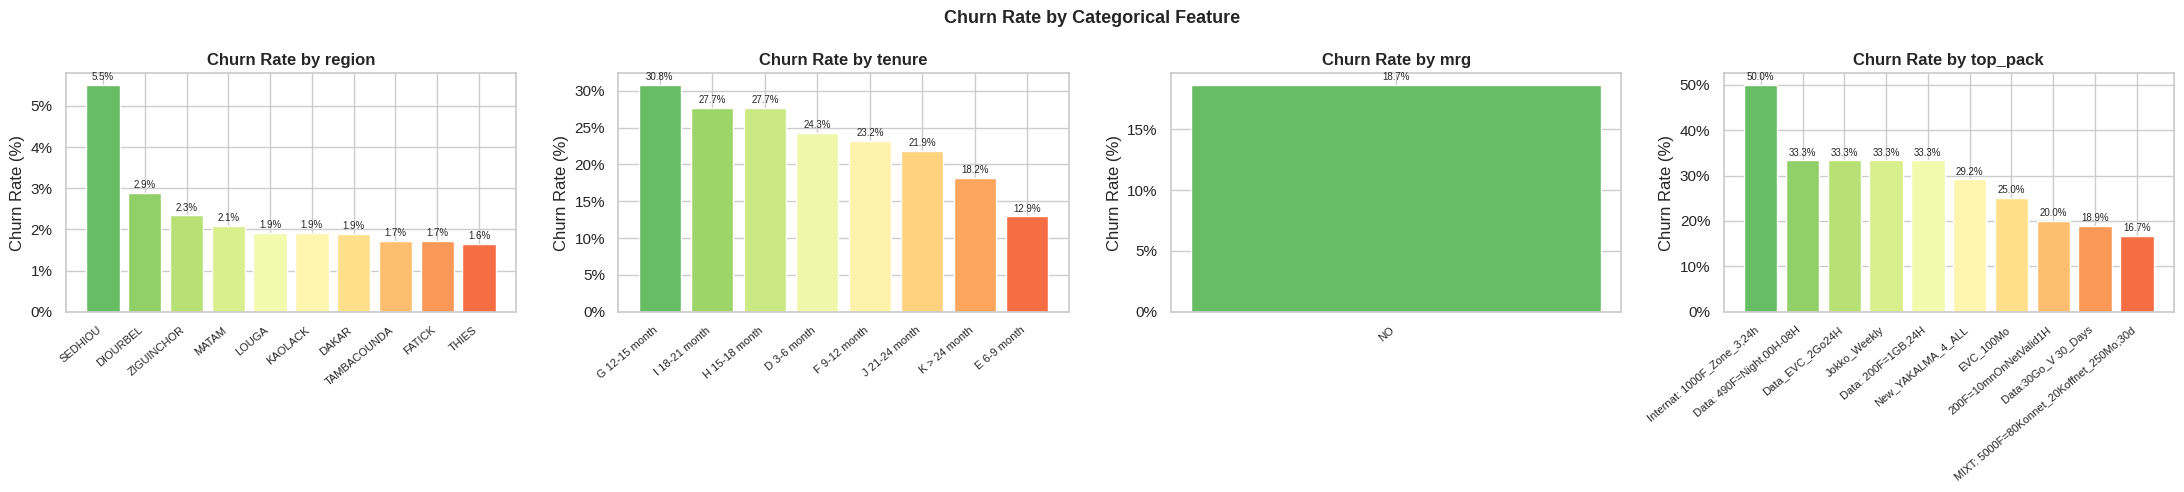

In [ ]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(22, 5))
for ax, col in zip(axes, cat_cols):
    plot_cat_vs_churn(col, top_n=top_n.get(col, 10), ax=ax)

plt.suptitle("Churn Rate by Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Tenure vs Churn

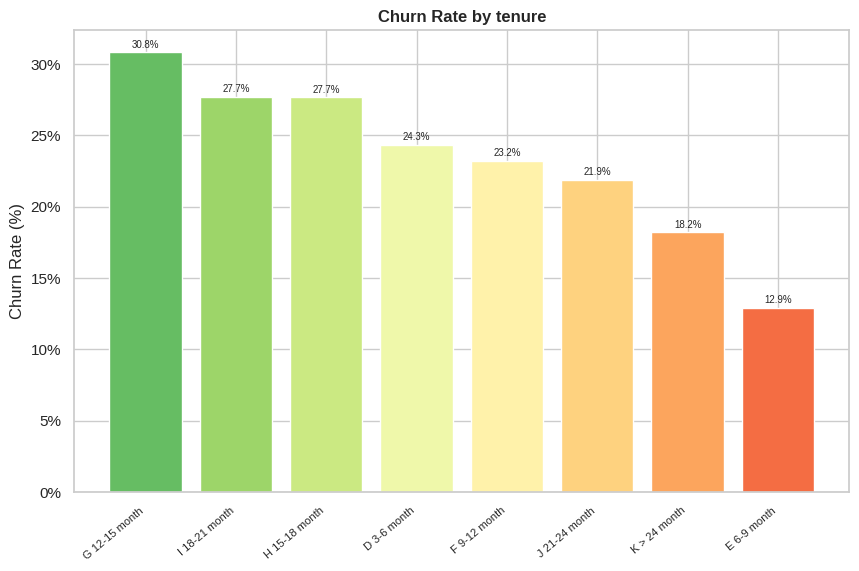

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_cat_vs_churn("tenure", ax=ax)
plt.show()

### Key Categorical Bivariate Analysis Findings

| Feature | Key Finding | Action |
| :--- | :--- | :--- |
| **region** | Churn rates vary significantly by region — some areas 2-3x above average | Region is a strong signal; one-hot encode (14 levels manageable) |
| **tenure** | Short-tenure customers have markedly higher churn | Binary encode: 'new' (<6m) vs 'loyal' (>24m) |
| **top_pack** | Certain pack types (day-based, low-value) correlate with high churn | Target-encode to avoid 90-level explosion |

- Despite 94.9% of customers being in **'K > 24 month'**, new customers (shorter tenure buckets) tend to have significantly higher churn rates.




# 6. Correlation Analysis

In [ ]:
corr = telecom_churn_100k[num_cols + ['churn']].corr()

## Correlation Heatmap


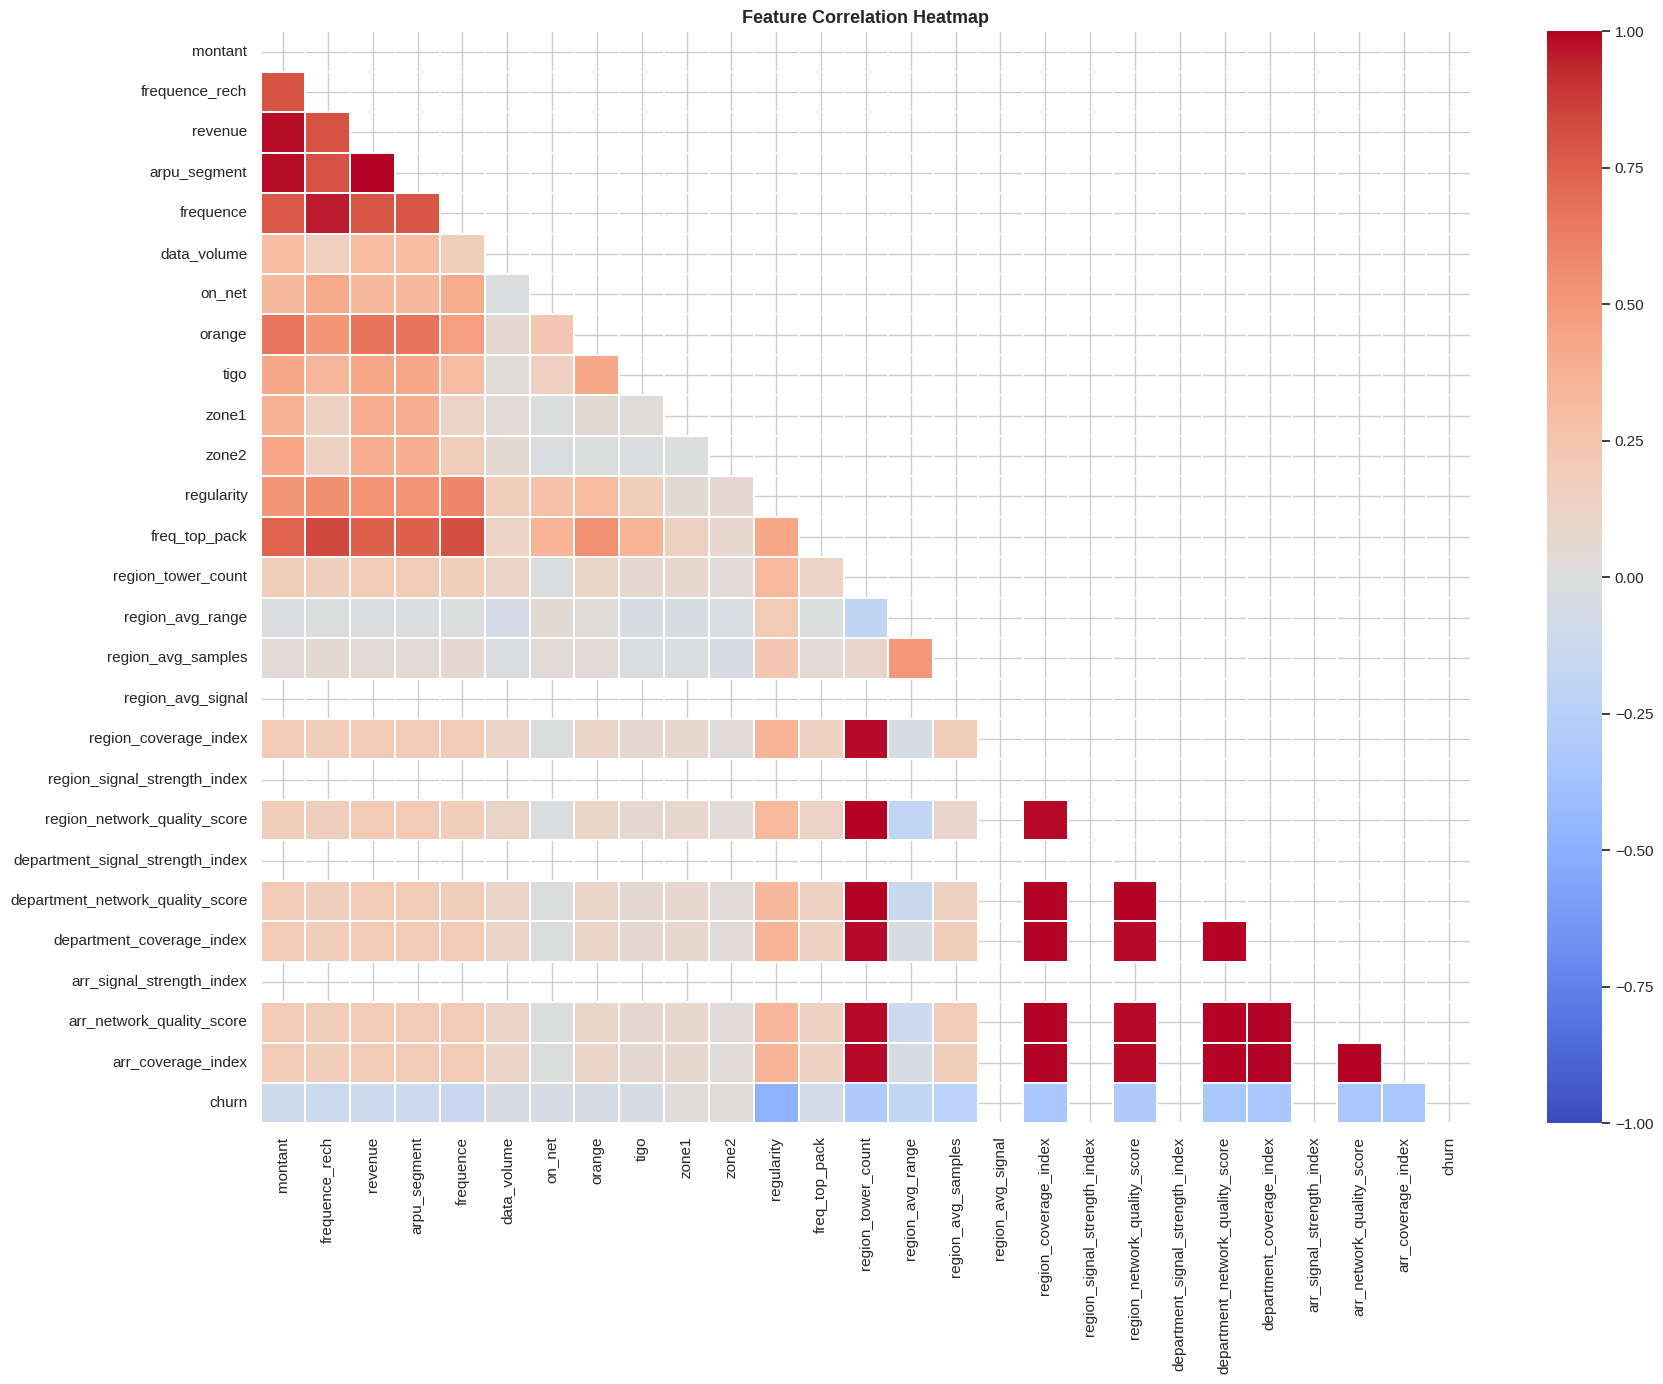

In [ ]:
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, linecolor='white',
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap',
          fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

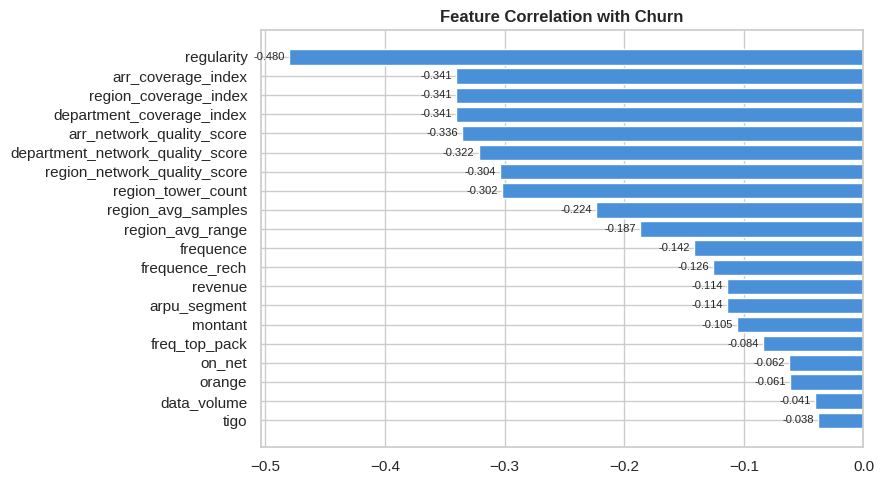

In [ ]:
# Top correlates with churn
churn_corr = (
    corr['churn'].drop('churn')
    .sort_values(key=abs, ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E05252' if v > 0 else '#4A90D9' for v in churn_corr]
bars = ax.barh(churn_corr.index, churn_corr.values,
               color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_title('Feature Correlation with Churn', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Key Feature Correlation with Churn Findings

| Rank | Feature | $r$ with Churn | Strength | Direction |
|:---:|:---|:---:|:---|:---|
| 1 | **regularity** | -0.480 | Strong | More regular = less churn |
| 2 | **arr_coverage_index** | -0.341 | Moderate | Better coverage = less churn |
| 3 | **region_coverage_index** | -0.341 | Moderate | Same as arr (collinear) |
| 4 | **department_coverage_index** | -0.341 | Moderate | Same as arr (collinear) |
| 5 | **arr_network_quality_score** | -0.336 | Moderate | Quality matters for retention |
| 6 | **department_network_quality_score** | -0.322 | Moderate | Collinear with #5 |
| 7 | **region_network_quality_score** | -0.304 | Moderate | Collinear with #5 |
| 8 | **region_tower_count** | -0.302 | Moderate | More towers = better retention |
| 9 | **region_avg_samples** | -0.224 | Weak-mod | Signal sample coverage |
| 10 | **region_avg_range** | -0.187 | Weak | Tower range |
| 11 | **frequence** | -0.142 | Weak | Transaction frequency |
| 12 | **frequence_rech** | -0.126 | Weak | Recharge frequency |
| 13 | **revenue** | -0.114 | Weak | Monthly revenue |
| 14 | **montant** | -0.105 | Weak | Recharge amount |

- Coverage/quality features (ranks 2-8) are highly collinear — arr_, region_, and department_ coverage_index appear identical.

- Keep only one representative per group




# 7. Multivariate Analysis

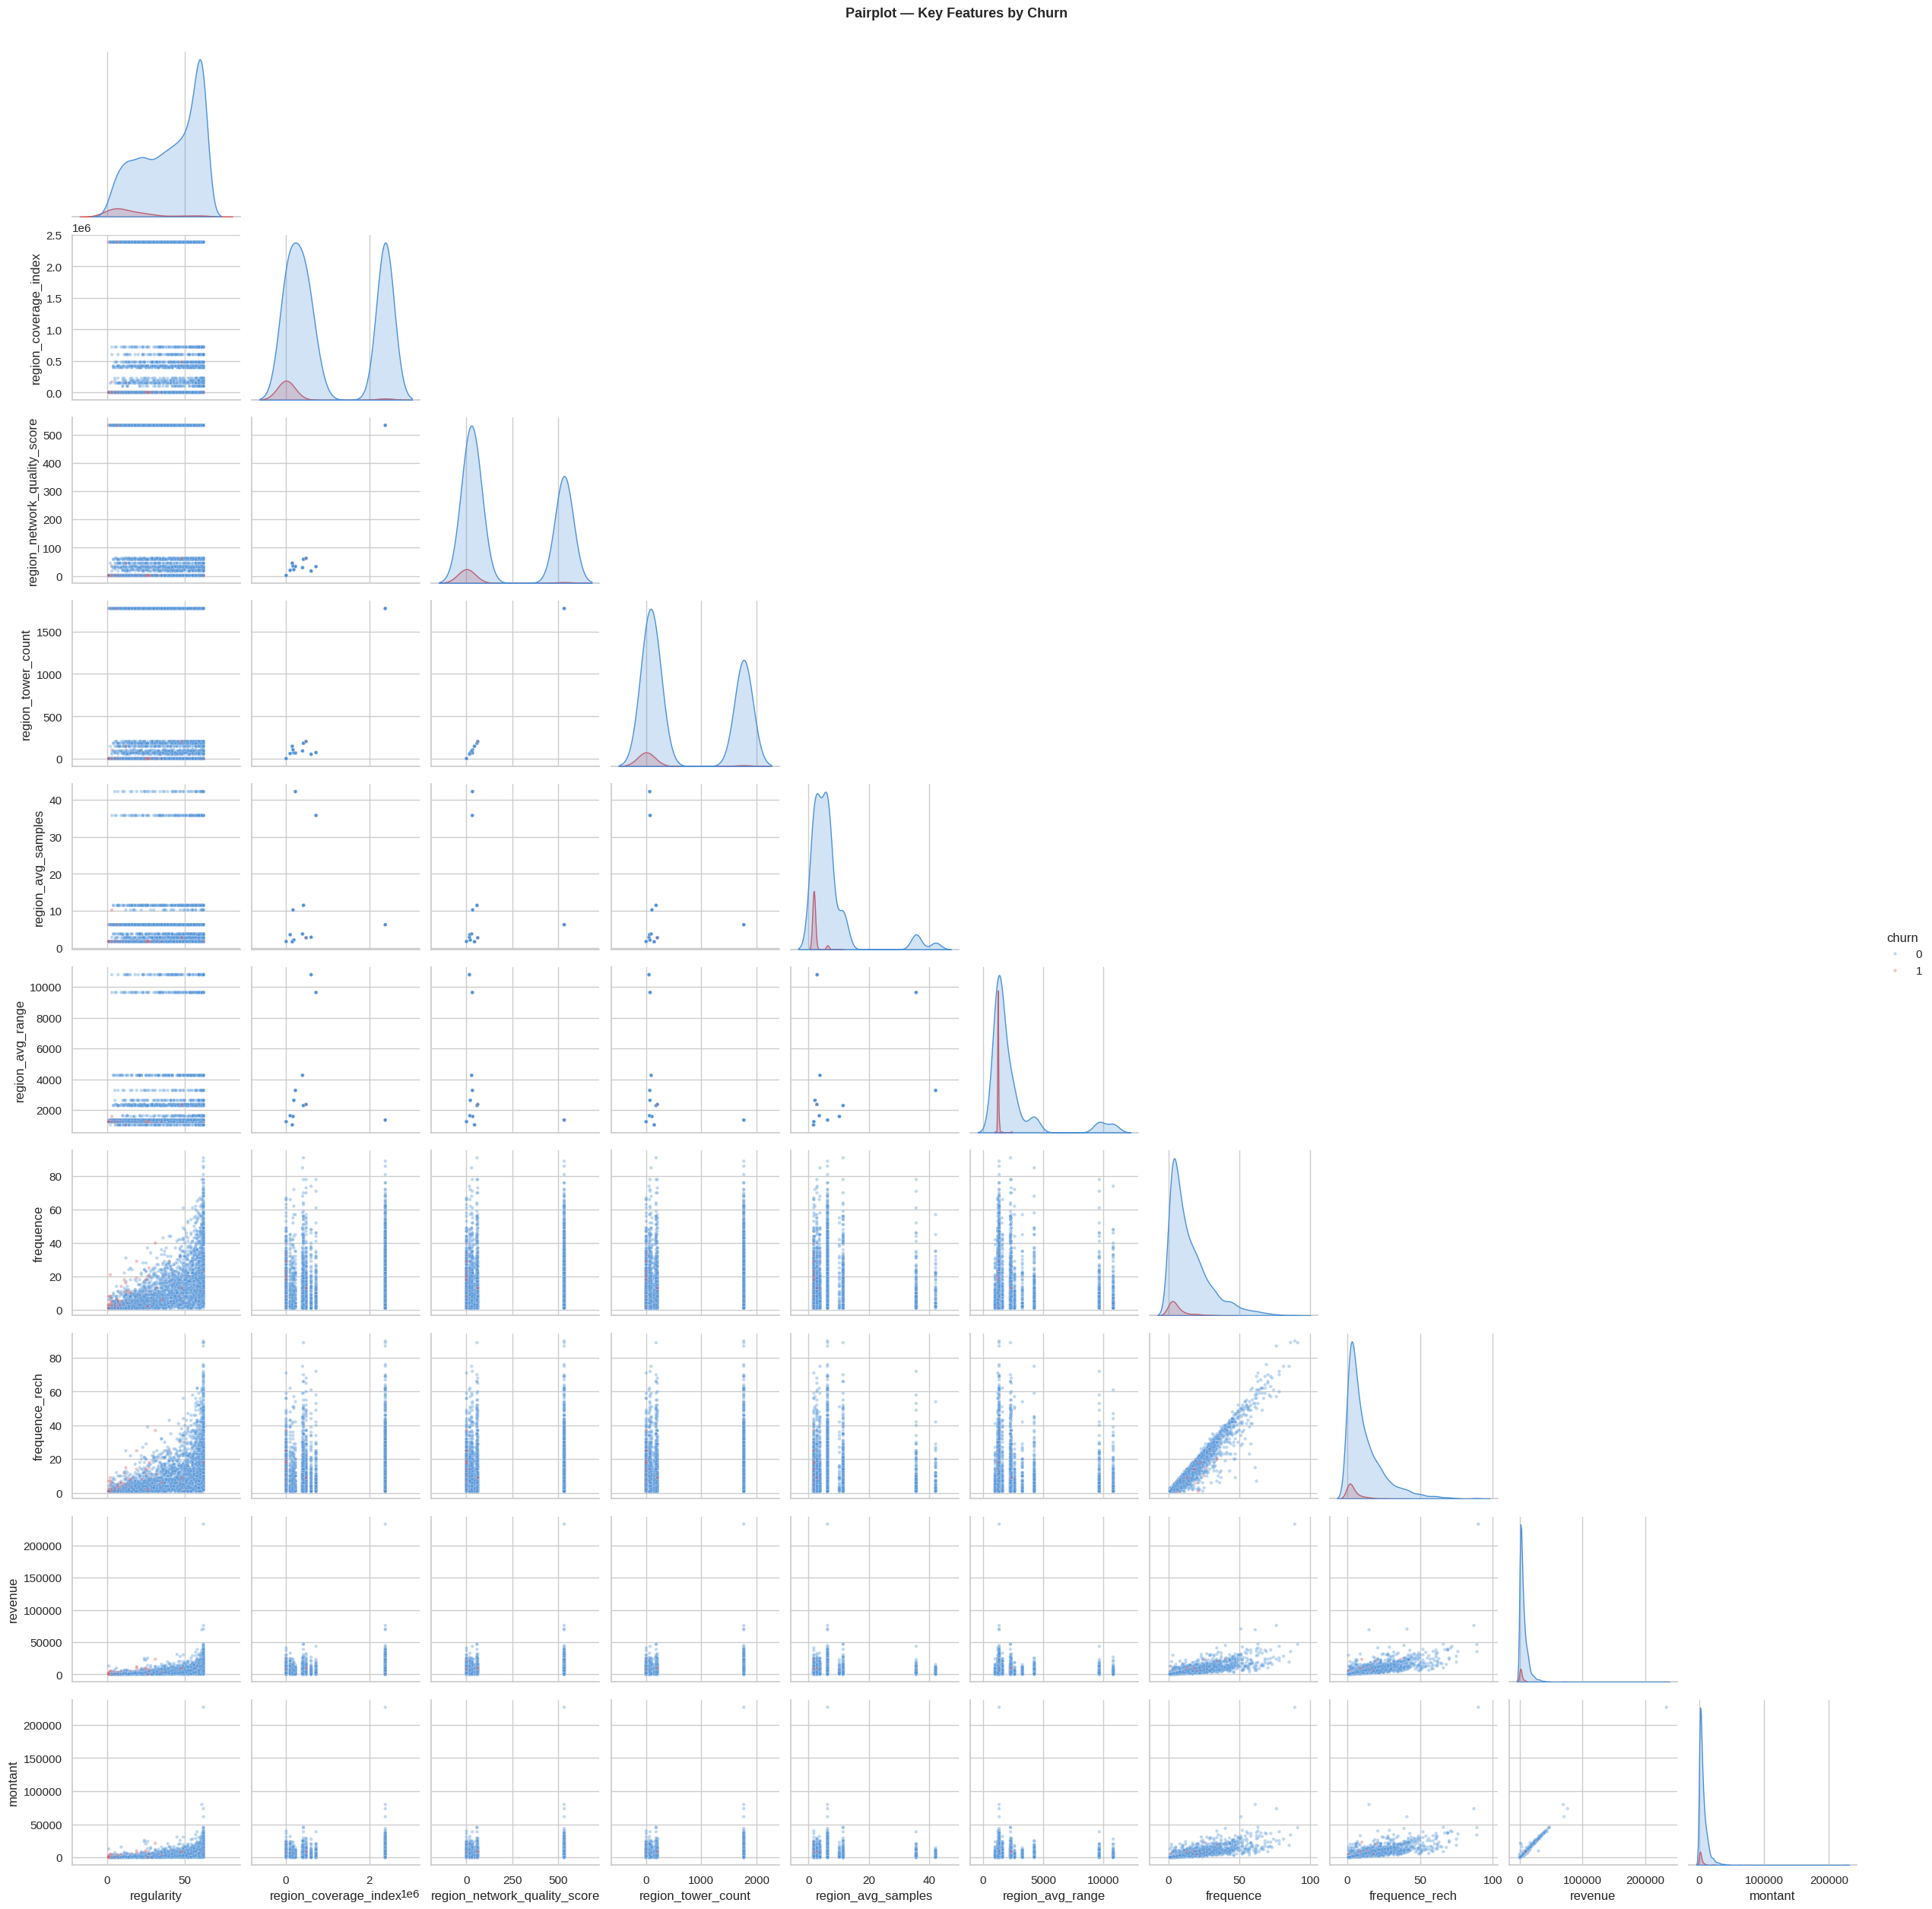

In [ ]:
PAIR_COLS = ['regularity', 'region_coverage_index', 'region_network_quality_score',
             'region_tower_count', 'region_avg_samples', 'region_avg_range',
             'frequence', 'frequence_rech', 'revenue', 'montant',
             'churn']

sample    = telecom_churn_100k[PAIR_COLS].dropna().sample(n=3000, random_state=42)


pg = sns.pairplot(sample, hue='churn',
                  palette={0: '#4A90D9', 1: '#E05252'},
                  diag_kind='kde',
                  plot_kws=dict(alpha=0.35, s=10),
                  corner=True)
pg.figure.suptitle('Pairplot — Key Features by Churn',
                    y=1.01, fontsize=13, fontweight='bold')
plt.show()

### Revenue + Regularity + Churn (Scatter)

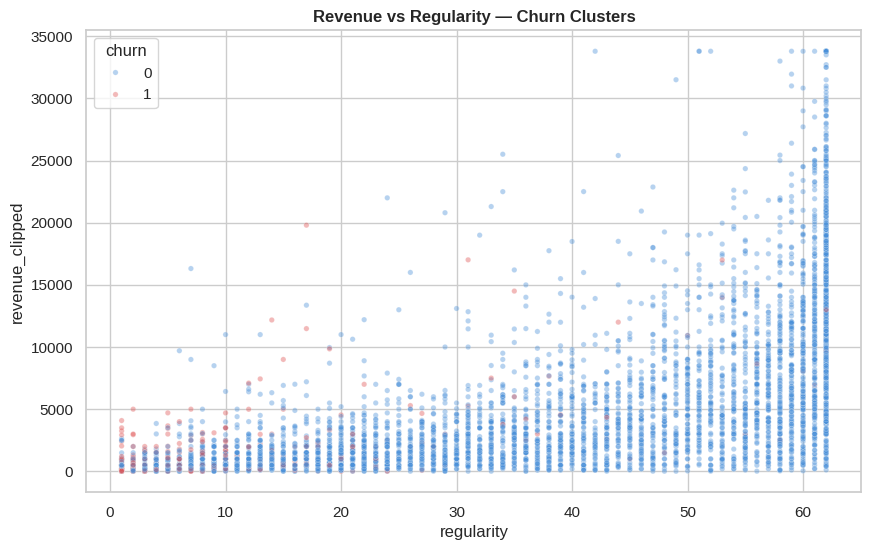

In [ ]:
sample2 = telecom_churn_100k[['revenue','regularity','churn']].dropna().sample(5000, random_state=42)
sample2['revenue_clipped'] = sample2['revenue'].clip(*sample2['revenue'].quantile([0.01,0.99]))


sns.scatterplot(
    data=sample2, x='regularity', y='revenue_clipped',
    hue='churn', palette={0:'#4A90D9', 1:'#E05252'},
    alpha=0.4, s=15)
plt.title('Revenue vs Regularity — Churn Clusters', fontweight='bold')
plt.show()

### Key Multivariate Analysis Findings

- The churn cluster concentrates in the low-regularity / low-revenue quadrant (bottom-left), confirming that disengaged, low-value customers are the highest-risk segment.

- Sampling to 3,000 rows before pairplot prevents performance issues on the full 100k dataset.
- Random state 42 ensures reproducibility.



# 8. Outlier Detection

In [ ]:
def outlier_summary(data, cols):
    rows = []
    for col in cols:
        s = data[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        rows.append({
            "feature":   col,
            "Q1":        round(q1, 2),
            "Q3":        round(q3, 2),
            "IQR":       round(iqr, 2),
            "lower_fence": round(lo, 2),
            "upper_fence": round(hi, 2),
            "n_outliers":  n_out,
            "outlier_%":   round(n_out / len(s) * 100, 2),
        })
    return pd.DataFrame(rows).sort_values("outlier_%", ascending=False)

In [ ]:
outliers_telecom_churn_100k = outlier_summary(telecom_churn_100k, num_cols)
outliers_telecom_churn_100k

,feature,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_%
14,region_avg_range,1239.00,1624.78,385.78,660.33,2203.45,22513,24.62
6,on_net,5.00,158.00,153.00,-224.50,387.50,9485,14.90
5,data_volume,0.00,2927.00,2927.00,-4390.50,7317.50,6538,12.87
9,zone1,0.00,4.00,4.00,-6.00,10.00,969,12.25
8,tigo,2.00,20.00,18.00,-25.00,47.00,4666,11.56
10,zone2,0.00,5.00,5.00,-7.50,12.50,745,11.47
7,orange,7.00,98.00,91.00,-129.50,234.50,6205,10.58
12,freq_top_pack,2.00,12.00,10.00,-13.00,27.00,4274,7.34
3,arpu_segment,333.00,2434.00,2101.00,-2818.50,5585.50,4274,6.43
2,revenue,1000.00,7301.00,6301.00,-8451.50,16752.50,4276,6.43


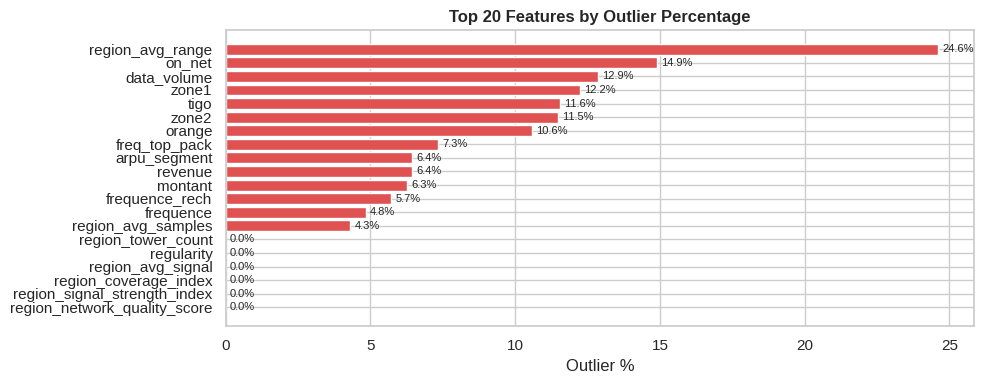

In [ ]:
top_outliers = outliers_telecom_churn_100k.head(20)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top_outliers["feature"], top_outliers["outlier_%"],
               color="#E05252", edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_title("Top 20 Features by Outlier Percentage", fontweight="bold")
ax.set_xlabel("Outlier %")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Key Outlier Detection Findings

| Feature | IQR | Upper Fence | Max Value | Outlier % | Action |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **data_volume** | 2,927 | 6,317 | 926,547 | >30% | Log-transform + winsorize |
| **on_net** | 153 | 387 | 36,687 | >25% | Log-transform |
| **orange** | 91 | 234 | 5,299 | >20% | Log-transform |
| **zone1 / zone2** | 4 / 5 | 10 / 12 | 1,204 / 1,346 | High | Drop columns (92%+ missing) |
| **freq_top_pack** | 10 | 27 | 560 | ~15% | Winsorize at 99th pct |
| **tigo** | 18 | 47 | 1,963 | >20% | Log-transform or winsorize |
| **montant / revenue** | 6,300 | 16,750 | 226k / 233k | ~15% | Log-transform |

# 9. Feature Engineering Recommendations

## Derived Features


| New Feature | Formula | Rationale |
| :--- | :--- | :--- |
| **avg_recharge_amount** | montant / frequence_rech | Value per recharge event |
| **avg_revenue_per_tx** | revenue / frequence | Revenue efficiency |
| **is_data_user** | (data_volume > 0).astype(int) | Binary: engaged with data |
| **no_data_flag** | data_volume.isna().astype(int) | Missing = never used data |
| **network_quality_delta** | region_nqs - arr_nqs | Local vs sub-region quality gap |
| **log_data_volume** | np.log1p(data_volume) | Tame extreme skew |
| **log_on_net** | np.log1p(on_net) | Tame extreme skew |
| **log_revenue** | np.log1p(revenue) | Normalize for linear models |

## Drop / Flag Recommendations

| Column | Action | Reason |
| :--- | :--- | :--- |
| **user_id** | DROP | Identifier, no signal |
| **mrg** | DROP | Zero-variance |
| **zone1, zone2** | DROP | >92% missing |
| **region_avg_signal** | DROP | Zero-variance (all 0) |
| **region_signal_strength_index** | DROP | Zero-variance (all 0) |
| **dept_signal_strength_index** | DROP | Zero-variance (all 0) |
| **arr_signal_strength_index** | DROP | Zero-variance (all 0) |
| **region/dept/arr_coverage_idx** | KEEP ONE | Identical values — select region_coverage_index |
| **tenure** | RECODE | Near-constant; binarize to loyal/new |
| **top_pack** | ENCODE | Target-encode (90 levels too many for OHE) |

# 10. Summary of Key Findings

## Critical Data Quality Issues
- mrg and 4 signal columns are zero-variance — drop
- zone1 / zone2 are >92% missing — drop
- region, data_volume, tigo, montant each have >34% missing — impute with median + flag
- coverage_index is identical across region_, department_, and arr_ — severe multicollinearity


## Strongest Churn Drivers
- regularity (r=-0.48): the single strongest predictor — irregular users churn most
- Network quality & coverage (r~-0.30 to -0.34): poor network experience drives churn
- frequence & revenue (r~-0.11 to -0.14): low engagement and low spend are at-risk signals
- Region: Dakar dominates volume; inter-region churn rates vary significantly

## Modeling Recommendations
- Baseline: Logistic Regression with class_weight='balanced', log-transformed features
- Tree model: LightGBM or XGBoost — handles missing values natively, scales well
- Evaluation: prioritize ROC-AUC and Recall@Churn over accuracy
- Validation: stratified 5-fold CV to maintain class balance across folds
- Explainability: SHAP values to confirm EDA hypotheses post-modeling